## Exercise 1

- Interpolate the missing values in the "PM_Nongzhanguan" series
and plot the last 42 days of the series to get a feel for the data
- Extract the train and test data for the "PM_Nongzhanguan" series
using the function get_train_test_data. Use the following set of
parameters:series_days : 56 ;input_hours : 12; test_hours : 48

- For reference, below is how we called the function earlier on. You
can also pull up the function documentation to review the various
arguments.
- Using the extracted train data to fit a simple RNN and use the test
data to generate and plot predictions.
- Start with a simple baseline - few cell units and epochs. From
here, try to make the model more expressive by increasing units
and epochs until you're satisfied with the model's predictions.
- Be careful not to set units and/or epochs too high. The model may
become very slow to train and also start to badly overfit the
training data with the extra complexity you've added.

#### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM

#### Dataset

In [2]:
df=pd.read_csv('Appendix 2 - Beijing.csv')

#### Interpolate "PM_Nongzhanguan"

A datetime variable was first constructed by combining the year, month, day, and hour columns to properly represent the temporal structure of the dataset. The data were then sorted in chronological order based on this new datetime variable to ensure a correct time sequence. Finally, missing values in the PM_Nongzhanguan series were handled using linear interpolation, which estimates missing observations by assuming a linear progression between neighboring known values. This approach allows for a smoother and more continuous representation of the time series while preserving its overall trend.

In [3]:
df['date'] = pd.to_datetime(df[['year','month','day','hour']])
df = df.sort_values('date')

df['PM_Nongzhanguan_interp'] = df['PM_Nongzhanguan'].interpolate(method='linear')

#### Plot last 42 days

The time series of PM2.5 concentrations at the Nongzhanguan station over the last 42 days shows significant variability and several pronounced pollution peaks. There are periods where PM2.5 levels rise sharply, reaching values above 500, indicating severe air pollution episodes. These peaks are interspersed with intervals of relatively low concentrations, suggesting fluctuations in atmospheric conditions such as wind, temperature, or human activity. Additionally, some recurring patterns can be observed, which may indicate short-term cyclical behavior, possibly linked to daily emission cycles or meteorological factors. Overall, the series reflects a highly dynamic and irregular pattern of air quality over time.

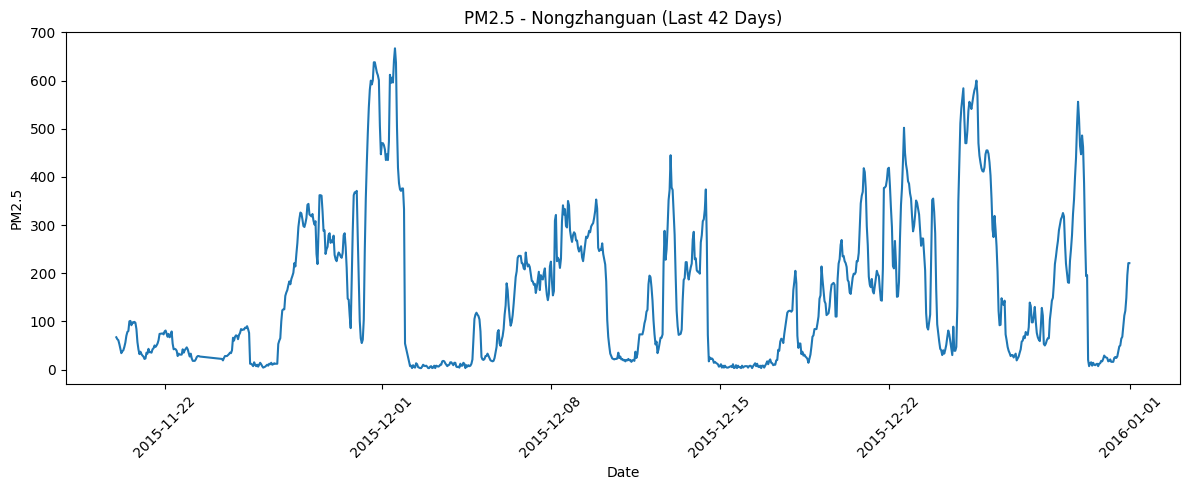

In [13]:
last_42_days = df.tail(42 * 24)
plt.figure(figsize=(12,5))

plt.plot(
    last_42_days['date'],
    last_42_days['PM_Nongzhanguan_interp']
)

plt.title("PM2.5 - Nongzhanguan (Last 42 Days)")
plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Making the function get_train_test_data

Several helper functions were created to organize and prepare the time series before applying the model. First, a function was defined to extract the last *n* days of the series, considering that the data is recorded hourly, so the last $24 \times n\_days$ observations are selected. This allows the analysis to focus on the most recent behavior of the variable. In addition, a plotting function was implemented to visualize this segment of the series, making it easier to identify patterns, peaks, and variability in air quality.

Furthermore, a function was developed to transform the series into a format suitable for neural networks by converting it into a three-dimensional array, where each sample contains its time steps and a single feature. Finally, a main function was created to split the data into training and testing sets. This function generates input-output sequences using a sliding window approach, where each input consists of a fixed number of past hours and the output corresponds to the next value. It also separates the most recent data for evaluation, allowing the model to be tested on unseen observations.

In [4]:
def get_keras_format_series(series):
 
    
    series = np.array(series)
    return series.reshape(series.shape[0], series.shape[1], 1)

def get_train_test_data(df, series_name, series_days, input_hours, 
                        test_hours, sample_gap=3):
    
    
    forecast_series = get_n_last_days(df, series_name, series_days).values

    train = forecast_series[:-test_hours]
    test = forecast_series[-test_hours:]

    train_X, train_y = [], []

    for i in range(0, train.shape[0]-input_hours, sample_gap):
        train_X.append(train[i:i+input_hours])
        train_y.append(train[i+input_hours])

    train_X = get_keras_format_series(train_X)    
    
    test_X_init = test[:input_hours]
    test_y = test[input_hours:]
    
    return train_X, test_X_init, train_y, test_y

In [6]:
def get_n_last_days(df, series_name, n_days):
    """
    Extract last n_days of an hourly time series
    """
    
    return df[series_name][-(24*n_days):] 


#### Extract the train and test data for the "PM_Nongzhanguan"

The train and test datasets were extracted using the `get_train_test_data` function applied to the interpolated PM_Nongzhanguan time series. A total of 56 days of hourly data were selected, ensuring that the analysis focuses on the most recent observations. Each input sequence was defined to include the previous 12 hours, which are used by the model to learn temporal patterns in the data. The last 48 hours of the series were reserved as test data, allowing the model’s performance to be evaluated on unseen observations. As a result, the function returns the training inputs and targets, along with the initial test sequence and the corresponding true values for comparison.

In [23]:
train_X, test_X_init, train_y, test_y = get_train_test_data(
    df,
    series_name='PM_Nongzhanguan_interp',
    series_days=56,
    input_hours=12,
    test_hours=48
)

#### RNN

Recurrent neural networks (RNNs) are a type of deep learning architecture specifically built to work with sequential data. In contrast to feedforward neural networks, RNNs can retain information from earlier inputs through an internal state, allowing them to capture dependencies across a sequence. This capability makes them particularly effective for tasks where the order and context of data are important, such as natural language processing, speech recognition, and time series prediction(Mienye et al., 2024).

#### RNN Model Setup

A simple Recurrent Neural Network (RNN) model was defined using a Sequential architecture. The model consists of a SimpleRNN layer with 10 units and a hyperbolic tangent (tanh) activation function, which processes input sequences of 12 time steps and one feature. This layer is followed by a Dense output layer that produces a single predicted value. The model was then compiled using the Adam optimizer and mean squared error (MSE) as the loss function, making it suitable for a regression task on time series data.

In [44]:
model = Sequential([
    SimpleRNN(units=10, activation='tanh', input_shape=(12,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

#### Fit model and making predictions

The model was trained using the prepared training data, where sequences of 12 previous observations were used to learn how to predict the next value in the series. This was done over a small number of epochs to establish a simple baseline model. After training, predictions were generated for the test period using a recursive approach. Starting with an initial input sequence from the test data, the model produced a prediction which was then appended to the input while removing the oldest value. This updated sequence was used to generate the next prediction, and the process was repeated iteratively. In this way, multiple future time steps were forecasted, allowing the model’s predictions to be compared with the actual observed values.

In [45]:
model.fit(
    train_X,
    np.array(train_y),
    epochs=10,
    verbose=1
)

predictions = []

current_input = test_X_init.copy()

for i in range(len(test_y)):
    
    current_input_reshaped = current_input.reshape(1, 12, 1)
    
    pred = model.predict(current_input_reshaped, verbose=0)[0][0]
    
    predictions.append(pred)
    
   
    current_input = np.append(current_input[1:], pred)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 41547.3984
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41492.6641 
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41445.6211 
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41400.2656 
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41354.1875 
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41308.7070 
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41262.3398 
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41214.0898 
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41093.8789 
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40797.5977 


#### Plot Predictions

The comparison between the real and predicted values shows that the model is not able to capture the variability of the time series. While the actual observations fluctuate across a wide range of values, the predicted outputs remain within a very narrow interval and quickly converge to a nearly constant value. This behavior results in a flat line in the prediction plot, indicating that the model is not learning the underlying temporal dynamics of the data.

This outcome is typical when using a simple RNN with limited capacity and few training epochs, as the model tends to approximate an average value rather than capturing complex patterns. Although the implementation and workflow are correct, the results suggest that the model is underfitting the data. Therefore, it is necessary to increase the model’s complexity—such as using more units or training for more epochs—to improve its predictive performance.

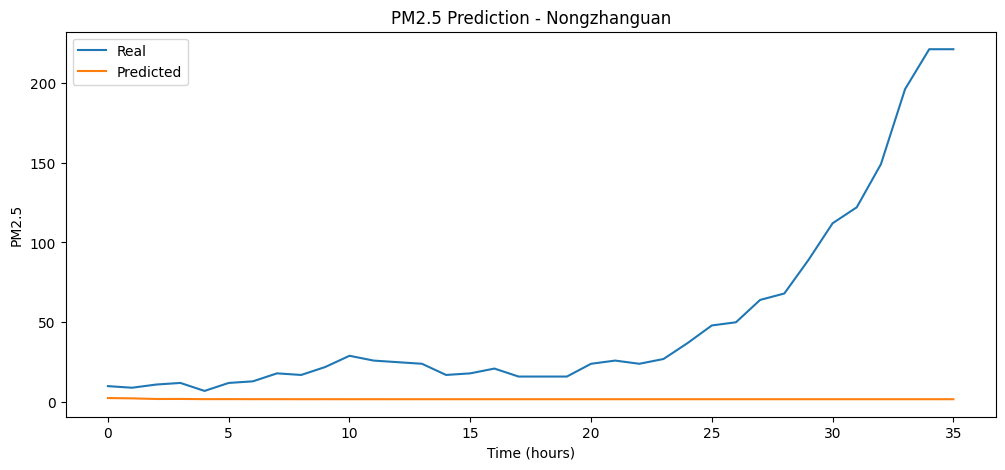

In [46]:

plt.figure(figsize=(12,5))

plt.plot(test_y, label='Real')
plt.plot(predictions, label='Predicted')

plt.title("PM2.5 Prediction - Nongzhanguan")
plt.xlabel("Time (hours)")
plt.ylabel("PM2.5")

plt.legend()
plt.show()

#### RNN Model (50 Units, 150 Epochs)

The model shows a clear improvement compared to previous configurations, as it is able to capture the initial upward trend of the time series and produce predictions that vary over time. Unlike simpler models, it does not collapse to a constant value and demonstrates a better understanding of the temporal structure in the data.

However, the model still struggles to accurately represent higher values and extreme peaks. After an initial period of growth, the predictions begin to stabilize and converge to a nearly constant level, failing to follow the sharp increases observed in the real data. This suggests that while the model has improved its ability to learn general patterns, it still lacks the capacity to fully capture the magnitude of rapid changes in the series.

In [125]:
model = Sequential([
    SimpleRNN(units=50, activation='tanh', input_shape=(12,1)),
    Dense(1)
])

# Compilar
model.compile(optimizer='adam', loss='mse')

# Entrenar
model.fit(
    train_X,
    np.array(train_y),
    epochs=150,
    verbose=1
)

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 41828.7852
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41417.0547 
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41142.7070 
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40859.8320 
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40604.9531 
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40349.5938 
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39970.3398 
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39691.7656 
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39494.0781 
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39280.2305 
Epoch 11/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39075.4609 
Epoch 12/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38859.1836 
Epoch 13/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38601.6367 
Epoch 14/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38392.2188 
Ep

In [126]:
predictions = []

current_input = test_X_init.copy()

for i in range(len(test_y)):
    
    current_input_reshaped = current_input.reshape(1, 12, 1)
    
    pred = model.predict(current_input_reshaped, verbose=0)[0][0]
    
    predictions.append(pred)
    
    current_input = np.append(current_input[1:], pred)

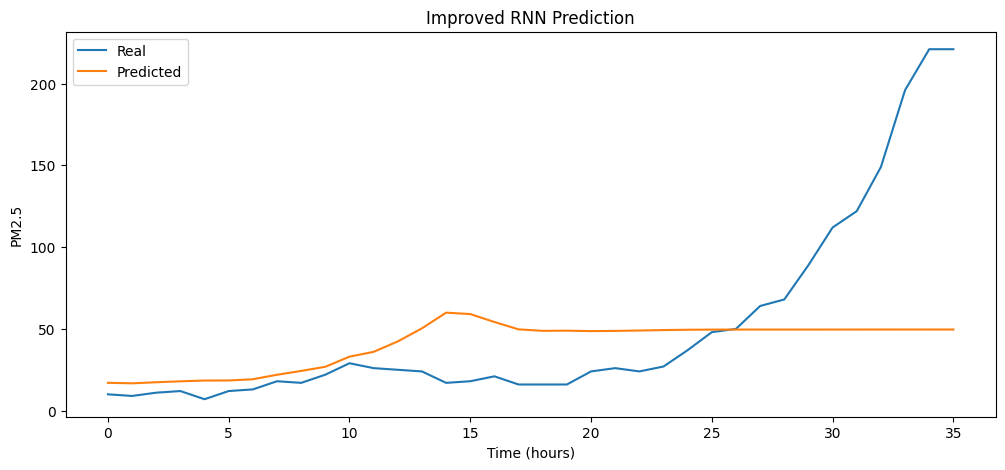

In [127]:
plt.figure(figsize=(12,5))

plt.plot(test_y, label='Real')
plt.plot(predictions, label='Predicted')

plt.title("Improved RNN Prediction")
plt.xlabel("Time (hours)")
plt.ylabel("PM2.5")

plt.legend()
plt.show()

#### RNN Model (30 Units, 500 epochs) 

This configuration shows a notable improvement in the model’s ability to capture both the trend and variability of the time series. Unlike previous models, the predictions exhibit dynamic behavior, following the general direction of the observed data and responding more effectively to changes over time. The model no longer produces flat or overly smooth outputs, indicating a better understanding of temporal patterns.

However, despite these improvements, the model still underestimates extreme values and fails to fully capture sharp peaks in the data. While the general shape of the series is well represented, the magnitude of rapid increases is not accurately reproduced. This suggests that although the model has become more expressive, further enhancements—such as more advanced architectures or data preprocessing—may be required to fully capture the complexity of the time series.

In [146]:
model = Sequential([
    SimpleRNN(units=30, activation='tanh', input_shape=(12,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    train_X,
    np.array(train_y),
    epochs=500,
    verbose=1
)

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 41898.2891
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41764.0547 
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41613.0312 
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41247.4922 
Epoch 5/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40938.6367 
Epoch 6/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40803.3789 
Epoch 7/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40610.8242 
Epoch 8/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40273.0664 
Epoch 9/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40033.3086 
Epoch 10/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39909.8281 
Epoch 11/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39768.5039 
Epoch 12/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39590.2188 
Epoch 13/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39383.9297 
Epoch 14/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39211.1172 
Ep

In [147]:
predictions = []

current_input = test_X_init.copy()

for i in range(len(test_y)):
    
    current_input_reshaped = current_input.reshape(1, 12, 1)
    
    pred = model.predict(current_input_reshaped, verbose=0)[0][0]
    
    predictions.append(pred)
    
    current_input = np.append(current_input[1:], pred)

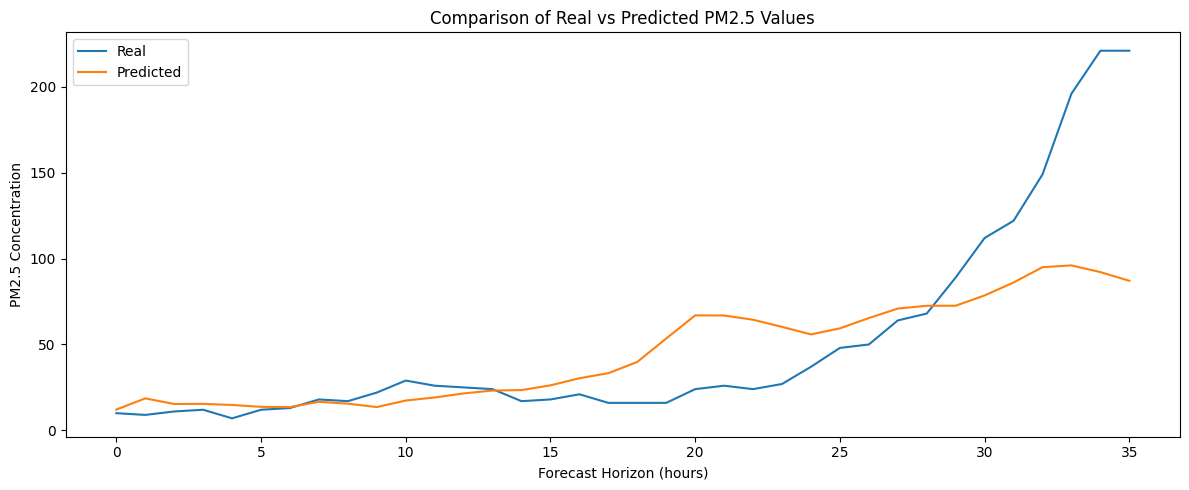

In [148]:
plt.figure(figsize=(12,5))

plt.plot(test_y, label='Real')
plt.plot(predictions, label='Predicted')

plt.title("Comparison of Real vs Predicted PM2.5 Values")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("PM2.5 Concentration")

plt.legend()


plt.tight_layout()
plt.show()

#### Final Review

The results highlight that the performance of recurrent neural networks depends not only on the model configuration but also on the characteristics of the data. In this case, the air pollution time series presents high variability and sudden increases in PM2.5 levels, which required a more expressive configuration to capture both trends and short-term fluctuations. The selected model was able to follow the general behavior of the series, although it still underestimated extreme values. This suggests that, for environmental data such as air quality, models need enough flexibility to adapt to abrupt changes and irregular patterns.

From an applied perspective, this behavior is not universal across all contexts. For example, in financial time series such as stock prices, although there is volatility, models often benefit from capturing trends without overreacting to noise. In contrast, in applications like energy consumption or temperature forecasting, the data tends to follow smoother and more regular patterns, where simpler models with fewer units and epochs may perform adequately. Similarly, in demographic or population data, where changes occur gradually over time, highly complex models may be unnecessary and could even lead to overfitting. Therefore, model selection and tuning should always be adapted to the specific nature of the problem, balancing complexity and generalization according to the behavior of the data.

#### Limitation

Simple RNN models present limitations when dealing with long sequences due to the vanishing gradient problem, which reduces their ability to retain information from earlier time steps. As a result, these models tend to focus on short-term patterns and may fail to capture more complex temporal dependencias (Arana, 2021)

This limitation is reflected in the results obtained, where the model struggles to reproduce sharp peaks and extreme variations in air pollution levels. While it is able to follow general trends, its inability to retain long-term information affects its predictive performance. Therefore, more advanced architectures such as LSTM could provide better results by addressing these limitations.


## Exercise 2

Adapt the code above from Example 2 in order to build an LSTM that
forecasts the "PM_Dongsi" series

- series_days : 50
- input_hours : 12
- test_hours : 48 

#### LSTM


The LSTM model is a type of recurrent neural network designed to address problems such as exploding and vanishing gradients, which often occur when learning long term dependencies. This is achieved through a mechanism called the constant error carousel, which allows the error signal to be preserved over time within each memory cell. These cells include recurrent connections and components such as input and output gates that regulate the flow of information.

A standard LSTM unit consists of a memory cell together with three main gates: input, output, and forget. The forget gate was introduced later to enable the network to reset or discard information when needed. The cell is responsible for storing information over extended periods, while the gates control what information is incorporated, maintained, or eliminated. Although this basic LSTM structure is the most commonly used, it is not always the best option in every context.(Van Houdt et al., 2020)


#### Exploration PM_Dongsi

As you can see, the PM2.5 time series at the Dongsi station exhibits a behavior very similar to the one observed in the previous station, with pronounced variability and recurring peak patterns. The series shows periods of relatively low pollution levels followed by sharp increases, reaching very high values, which indicates the presence of episodic pollution events. These peaks appear intermittently and suggest that air quality is influenced by dynamic environmental and possibly human-related factors.

Overall, the data reflects a highly volatile structure, with no constant trend but rather cycles of accumulation and dispersion of pollutants. This similarity across stations suggests that the underlying processes driving air pollution in the city are consistent, although the magnitude and timing of peaks may vary slightly depending on the location.

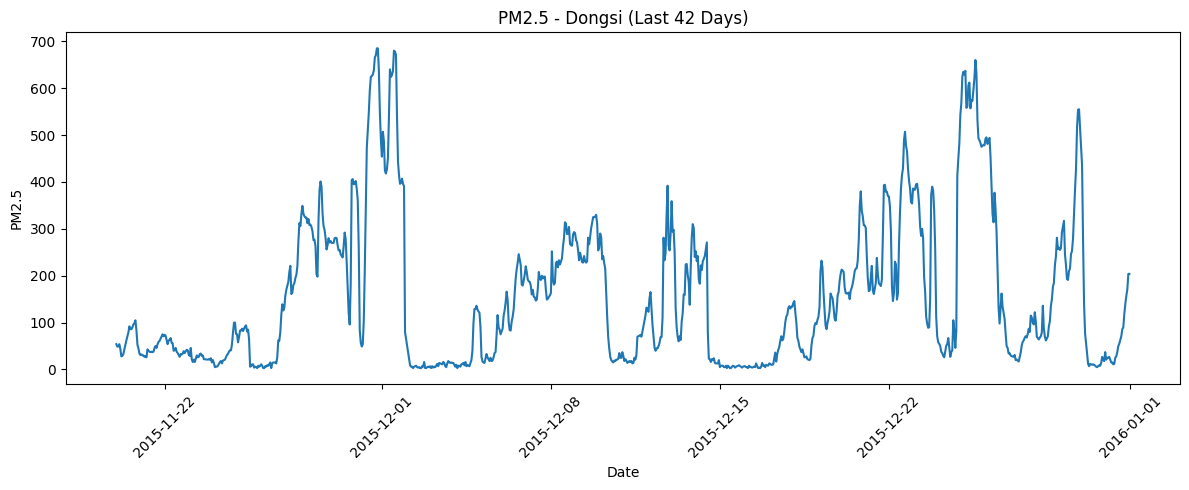

In [8]:
df['PM_Dongsi_interp'] = df['PM_Dongsi'].interpolate(method='linear')
last_42_days = df.tail(42 * 24)
plt.figure(figsize=(12,5))

plt.plot(
    last_42_days['date'],
    last_42_days['PM_Dongsi_interp']
)

plt.title("PM2.5 - Dongsi (Last 42 Days)")
plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Extract the train and test data for the "PM_Dongsi"

The training and testing datasets were extracted from the interpolated PM_Dongsi time series using the `get_train_test_data` function as well. A total of 50 days of hourly observations were selected to focus on recent behavior. The data was then structured into input-output sequences, where each input consists of the previous 12 hours and the corresponding target is the next value in the series. Additionally, the last 48 hours were reserved as test data to evaluate the model’s predictive performance on unseen observations. This process ensures that the data is properly formatted for time series forecasting using neural network models.

In [9]:
train_X, test_X_init, train_y, test_y = get_train_test_data(
    df,
    series_name='PM_Dongsi_interp',
    series_days=50,
    input_hours=12,
    test_hours=48
)

#### Simple Baseline LSTM

Similar to the baseline RNN model, the LSTM baseline produces nearly constant predictions with very low values, failing to capture both the variability and the increasing trend of the time series. Despite the LSTM architecture being designed to handle temporal dependencies more effectively, the configuration with a small number of units and epochs is not sufficient to learn meaningful patterns from the data. As a result, the model behaves like a simple approximation of the average, indicating the need for a more expressive configuration.

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 47283.2148
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47259.1680 
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47234.3672 
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47219.9375 
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47205.7266 
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47188.9414 
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 47164.5312 
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 47097.0508 
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46992.0195 
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 46964.3477 


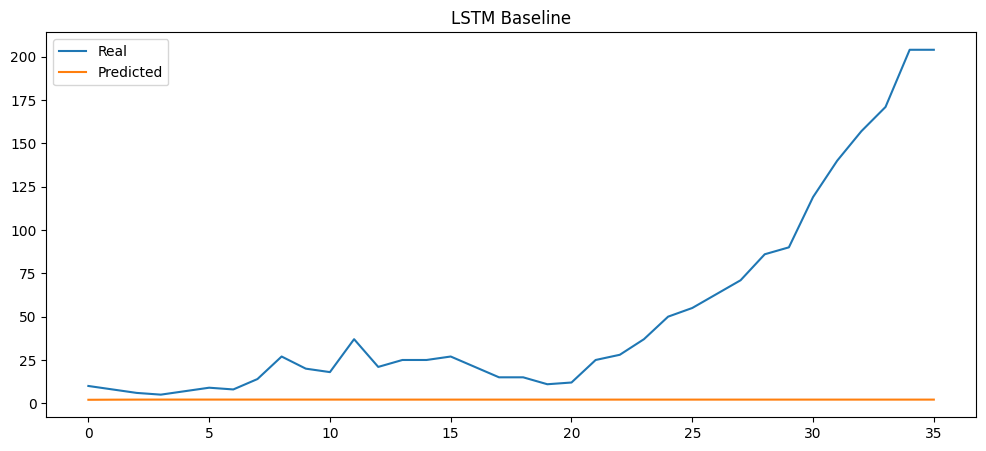

In [27]:
model = train_lstm_model(train_X, train_y, units=10, epochs=10)

predict_and_plot_lstm(model, test_X_init, test_y, 
                      title="LSTM Baseline")

#### Model 2: LSTM ( Units= 50, Epoch= 30)

The second LSTM model shows limited improvement over the baseline, as the predictions remain nearly constant and fail to capture the increasing trend observed in the real data. Despite increasing the number of units and training epochs, the model still approximates an average value and does not reflect the variability of the time series. This indicates that the model is underfitting and is not sufficiently expressive to learn the underlying temporal patterns.

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 47395.8828
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 47197.1719 
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46874.6992 
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46751.1953 
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46626.5703 
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46316.2109 
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45970.5938 
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45555.1484 
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45075.4727 
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44767.5117 
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44441.7852 
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 44199.6172
Epoch 13/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43960.1328 
Epoch 14/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 43693.3516 
Epoch 15/30
12/12

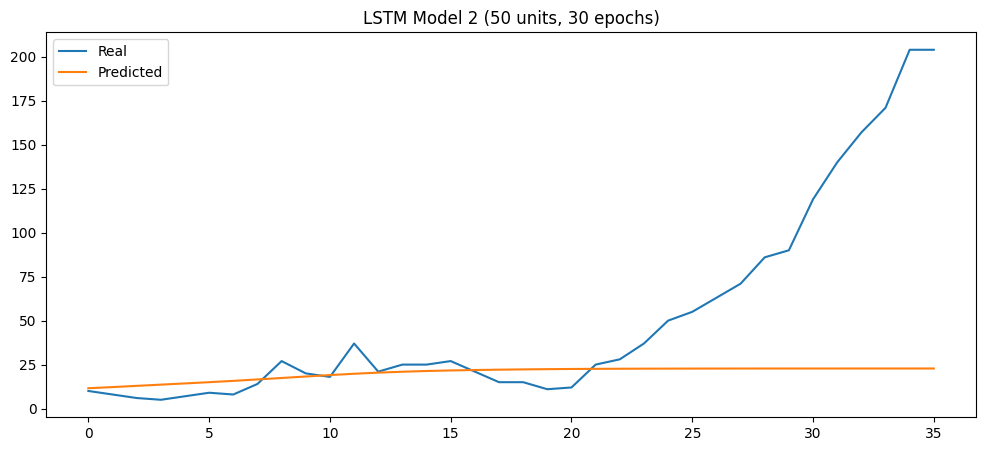

In [28]:
model = train_lstm_model(train_X, train_y, units=50, epochs=30)

preds = predict_and_plot_lstm(
    model, test_X_init, test_y,
    title="LSTM Model 2 (50 units, 30 epochs)"
)

#### Model 3: LSTM ( Units=100, Epoch=100)

The LSTM model with increased units and epochs shows a clear improvement compared to previous configurations, as it is able to capture the general upward trend of the time series. Unlike earlier models, the predictions are no longer constant and reflect changes in the data over time.

However, the model still fails to accurately represent the magnitude of the increase in the later periods, as the predictions stabilize and underestimate higher values. This indicates that while the model has learned part of the temporal structure, it still lacks the capacity to fully capture sharp growth and extreme values in the series.

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 47290.2383
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 46914.7461
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 46555.8477
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 46136.0586
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45420.7695
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 44607.4961
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 43546.5508
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 42761.9336 
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42245.7266 
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41835.9570 
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41449.9922 
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41072.1016 
Epoch 13/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40713.5625 
Epoch 14/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40392.4023 
Epoch 15

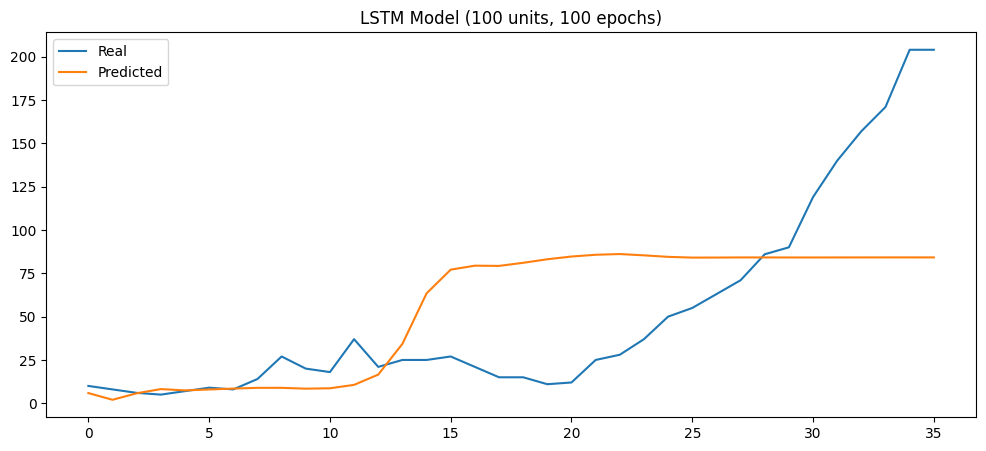

In [29]:
model = train_lstm_model(train_X, train_y, units=100, epochs=100)

preds = predict_and_plot_lstm(
    model, test_X_init, test_y,
    title="LSTM Model (100 units, 100 epochs)"
)

### Model 4: LSTM ( units= 100, Epoch= 250)

The LSTM model with a higher number of units and training epochs shows a significant improvement in capturing the overall trend of the time series. Unlike previous models, it is able to reflect the strong upward behavior observed in the data and produces dynamic predictions rather than constant values.

The model tends to anticipate the increase earlier than it occurs in reality, resulting in an overestimation of values during the later periods. This indicates that, while the model has learned the general structure of the series, it struggles with accurately modeling the timing of changes. Such behavior suggests a tendency toward overfitting or limited generalization in temporal dynamics.

Epoch 1/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 46920.0273
Epoch 2/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 46499.1836
Epoch 3/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45980.2852
Epoch 4/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45358.4531 
Epoch 5/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44662.6680 
Epoch 6/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 43925.8320
Epoch 7/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43233.6641
Epoch 8/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 42698.1094
Epoch 9/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42219.3398
Epoch 10/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41732.6406 
Epoch 11/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41352.5195 
Epoch 12/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41003.2500 
Epoch 13/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40665.8828 
Epoch 14/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40351.6328 
Epoch 15

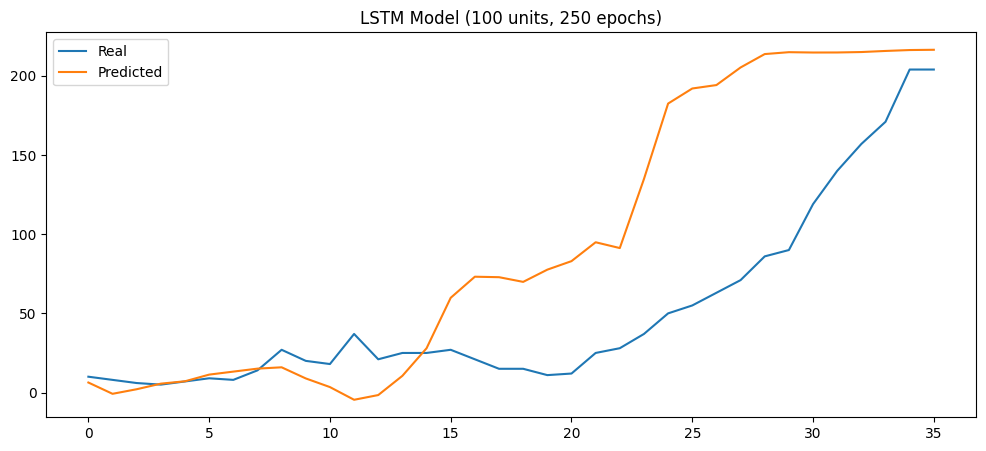

In [37]:
model = train_lstm_model(train_X, train_y, units=100, epochs=250)

predict_and_plot_lstm(
    model, test_X_init, test_y,
    title="LSTM Model (100 units, 250 epochs)"
)

The final LSTM model, configured with a higher number of units and training epochs, shows a clear improvement in capturing the overall trend of the PM2.5 time series. Unlike previous models, it produces dynamic predictions that follow the increasing behavior of the data, indicating that the model has learned relevant temporal patterns. However, the predictions tend to anticipate the rise earlier than it actually occurs and overestimate higher values, suggesting that the model does not accurately capture the timing and magnitude of changes.

This behavior is consistent with findings in the literature regarding the limitations of LSTM models. According to (Reddy, 2025), the high capacity of LSTM networks can lead to overfitting, particularly when dealing with noisy or highly variable data. In this case, the model appears to memorize patterns from the training data rather than generalizing effectively, which explains the early increase and overestimation observed in the predictions. This highlights the importance of carefully tuning model complexity to balance learning and generalization.


#### Conclusion

Overall, both approaches show that modeling air pollution as a time series is not trivial, especially given the variability and sudden peaks observed in the data. The RNN model, particularly with the configuration of 30 units and 500 epochs, provides more stable and consistent predictions, following the general trend without producing extreme or unrealistic values. Although it tends to underestimate higher pollution levels, it maintains a reasonable approximation of the series and avoids erratic behavior, making it a reliable baseline for this type of problem.

On the other hand, the LSTM model, especially with configurations such as 100 units and 250 epochs, demonstrates a greater capacity to capture complex patterns and strong upward trends, but this comes at the cost of stability. In this case, the model tends to anticipate increases earlier than they actually occur and overestimate higher values, suggesting difficulties in generalizing properly. This contrast highlights that a more complex model does not always guarantee better results, and that in practical applications, a balance between model capacity and generalization is often more valuable than simply increasing complexity.

In [16]:
def train_lstm_model(train_X, train_y, units=10, epochs=10):
    
    model = Sequential([
        LSTM(units=units, activation='tanh', input_shape=(train_X.shape[1],1)),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    train_y = np.array(train_y)
    
    model.fit(train_X, train_y, epochs=epochs, verbose=1)
    
    return model

In [26]:
def predict_and_plot_lstm(model, test_X_init, test_y, title="LSTM Model"):
    
    predictions = []
    current_input = test_X_init.copy()
    
    for i in range(len(test_y)):
        current_input_reshaped = current_input.reshape(1, 12, 1)
        
        pred = model.predict(current_input_reshaped, verbose=0)[0][0]
        predictions.append(pred)
        
        current_input = np.append(current_input[1:], pred)
    
    plt.figure(figsize=(12,5))
    plt.plot(test_y, label='Real')
    plt.plot(predictions, label='Predicted')
    plt.title(title)
    plt.legend()
    plt.show()